# [디지털 전환의 인식과 영향력] 분석
p_k05001 디지털 전환 인지 정도 k05002 디지털 전환 체감

p_k02001 ~ 7- 각 기술의 인지 정도

p_k_02008 ~ 14 - 삶에 미칠 영향력

p__k06001 - 챗봇 인지 정도 p__k06002 - 챗봇 이용 여부

p__k06003 이용 목적 05 유료 서비스 이용경험


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT_ROOT = '../../'

In [127]:
csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', '../../00_data/01_interim/selected_data_2023.csv')
data_2023_df = pd.read_csv(csv_path)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\3516899775.py:2: DtypeWarning: Columns (0: p__d26019, 1: p__d26064, 2: p__d26068, 3: p__d27007, 4: p__d28003, 5: p__d22007, 6: p__d26062, 7: p__a03012, 8: p__l01012, 9: p__l01015, 10: p__l01028, 11: p__k06004, 12: p__relig3, 13: p__d26088) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2023_df = pd.read_csv(csv_path)


## Chi-square 검정 함수

In [128]:
from scipy.stats import chi2_contingency

def get_cramers_v(df,col, col2='is_churned'):
    # 2-1. 교차표 생성
    contingency_table = pd.crosstab(df[col], df[col2])

    # 2-2. 카이제곱 검정 수행
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # 2-3. Cramér's V 계산 (효과 크기)
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

    return{
        'column': col,
        'p_value': p,
        'is_valid': p < 0.05,
        'cramers_v': cramers_v
    }

## Spearman 상관계수 계산 함수

In [129]:
import pandas as pd
from scipy.stats import spearmanr

def get_spearman_score(df, column_name, target='is_churned'):
    """
    특정 컬럼과 타겟 컬럼 사이의 스피어만 상관계수를 구하는 함수
    """
    # 1. 데이터 추출 및 결측치 제거 (상관계수 계산을 위해 필수)
    # 두 컬럼 중 하나라도 NaN인 행은 제외합니다.
    temp_df = df[[column_name, target]].dropna()

    if temp_df.empty:
        return print(f"⚠️ '{column_name}' 컬럼에 유효한 데이터가 없습니다.")

    # 2. 스피어만 상관계수 계산
    # rho: 상관계수 (-1 ~ 1)
    # p_val: 유의 확률 (0.05 미만일 때 통계적으로 유의)
    rho, p_val = spearmanr(temp_df[column_name], temp_df[target])

    # 3. 결과 출력
    print(f"🔍 [{column_name}] vs [{target}] 분석 결과")
    print(f"  - Spearman's Rho: {rho:.4f}")
    print(f"  - P-value: {p_val:.4e}")

    # 4. 간단한 해석 가이드
    if p_val < 0.05:
        direction = "양(+)의 상관관계 (수치가 커질수록 이탈률 증가)" if rho > 0 else "음(-)의 상관관계 (수치가 커질수록 이탈률 감소)"
        strength = "강함" if abs(rho) > 0.4 else "보통" if abs(rho) > 0.2 else "약함"
        print(f"  ✅ 결과: 통계적으로 유의미한 {strength} {direction}가 관찰됩니다.")
    else:
        print("  ❌ 결과: 통계적으로 유의미한 상관관계가 발견되지 않았습니다.")

    print("-" * 40)

# 사용 예시:
# get_spearman_score(train_df, 'p__age')

## DX를 알고있는가?

In [81]:
data_2023_df['p__k05001'].value_counts().sort_index()

p__k05001
1.0     130
2.0     879
3.0    1177
4.0      94
Name: count, dtype: int64

Spearman 상관계수 확인

In [131]:
get_spearman_score(data_2023_df, 'p__k05001')

🔍 [p__k05001] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0562
  - P-value: 7.3102e-03
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------


## 일상에서 체감하는가?

In [82]:
data_2023_df['p__k05002'].value_counts().sort_index()

p__k05002
1.0      51
2.0     234
3.0     819
4.0    1042
5.0     134
Name: count, dtype: int64

Spearman 상관계수 확인

In [132]:
get_spearman_score(data_2023_df, 'p__k05002')

🔍 [p__k05002] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0708
  - P-value: 7.1702e-04
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------


## 신기술별 인지 정도, 삶에 미치는 영향력


### 분포 확인

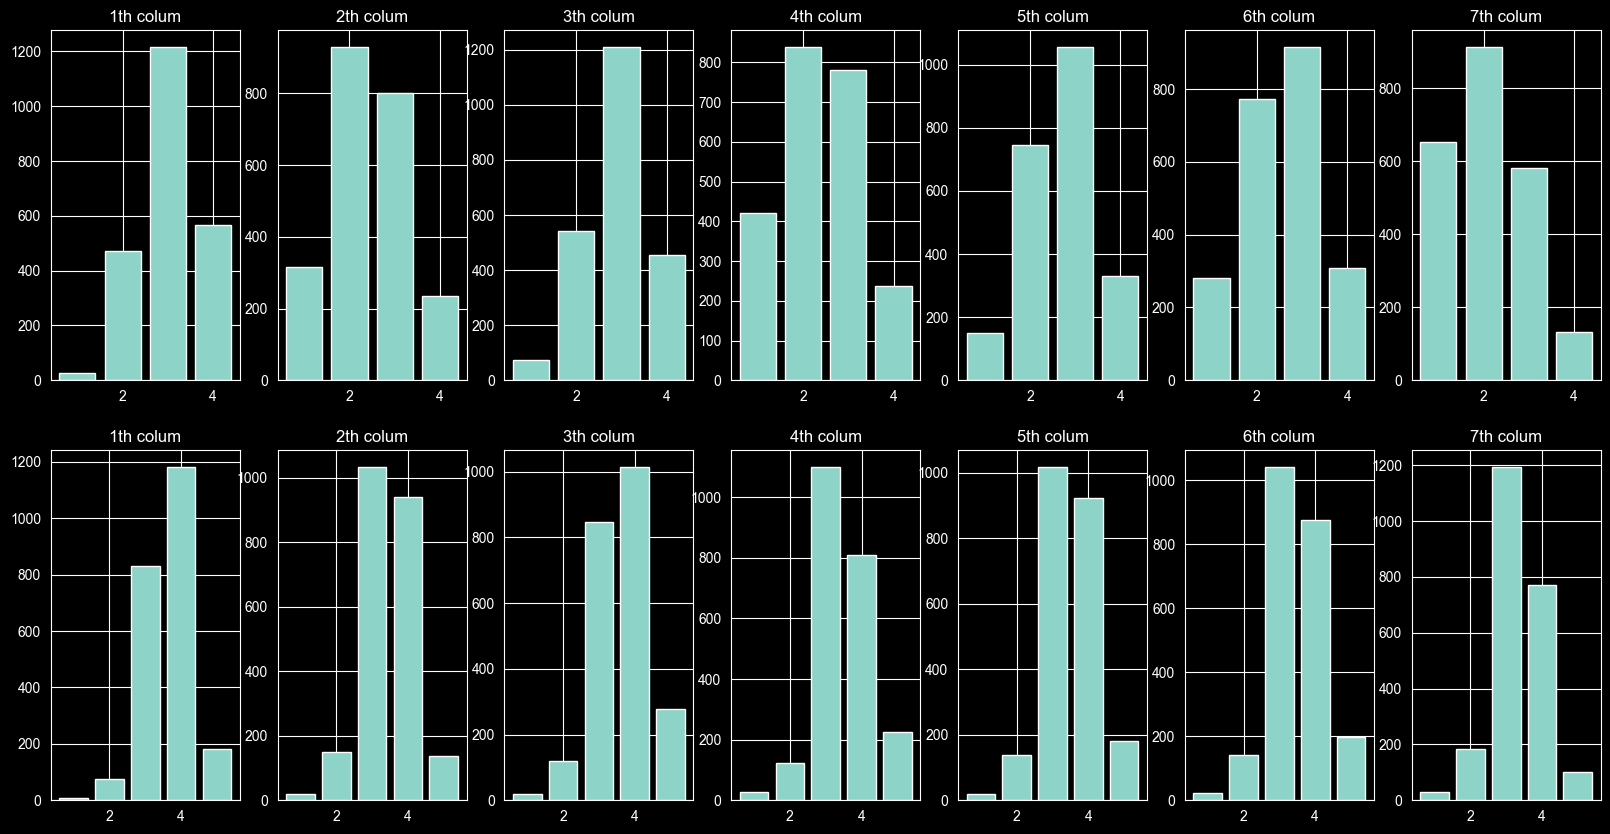

In [83]:
fig, ax = plt.subplots(2,7, figsize=(20,10))
for i in range(1, 15):
    col_name = 'p__k020'+str(i).zfill(2)
    row = (i-1) // 7
    col = (i-1) % 7
    res = data_2023_df[col_name].value_counts().sort_index()
    ax[row][col].bar(res.index, res.values)
    ax[row][col].set_title(f'{col+1}th colum')
plt.show()

### 이탈 여부와 Spearman 상관계수 확인

In [136]:
include_columns = ['p__k05001', 'p__k05002'] + ['p__k020'+str(i).zfill(2) for i in range(1, 15)] + ['p__k06001', 'p__k06002', 'p__k06003', 'p__k06005']
for col in include_columns:
    get_spearman_score(data_2023_df, col)

🔍 [p__k05001] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0562
  - P-value: 7.3102e-03
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------
🔍 [p__k05002] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0708
  - P-value: 7.1702e-04
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------
🔍 [p__k02001] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0677
  - P-value: 1.2120e-03
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------
🔍 [p__k02002] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0940
  - P-value: 6.9169e-06
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------
🔍 [p__k02003] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0310
  - P-value: 1.3898e-01
  ❌ 결과: 통계적으로 유의미한 상관관계가 발견되지 않았습니다.
----------------------------------------
🔍 [p__k02004] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0645
  - P-value: 2.064

## 관련성이 있어 보이는 컬럼들
Spearman 계수 0.1 이상인 컬럼

In [152]:
significant_features = ['p__k02006', 'p__k02007']

## 추가 분석
- 진짜 쓸만한가?

In [92]:
pd.crosstab(data_2023_df['p__k02006'], data_2023_df['is_churned'], normalize='index')  * 100 #신기술을 잘 알면 이탈 잘 안함

is_churned,0,1
p__k02006,,
1.0,53.024911,46.975089
2.0,61.111111,38.888889
3.0,67.139738,32.860262
4.0,70.550162,29.449838


In [93]:
pd.crosstab(data_2023_df['p__k02007'], data_2023_df['is_churned'], normalize='index')* 100

is_churned,0,1
p__k02007,,
1.0,56.049005,43.950995
2.0,64.184009,35.815991
3.0,68.556701,31.443299
4.0,78.787879,21.212121


### 중간 결론: 사물인터넷, 양자컴퓨팅에 대한 기술에 관심이 많은지에 따라 이탈률에 영향이 있다

### 젊은 사람이라 신기술을 잘 아는게 아닐까?

나이 컬럼과 Spearman 계수 계산

In [142]:
#get_cramers_v(data_2023_df, 'p__k02007','p__age')
get_spearman_score(data_2023_df, 'p__k02007', 'p__age')

🔍 [p__k02007] vs [p__age] 분석 결과
  - Spearman's Rho: -0.0998
  - P-value: 1.7967e-06
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------


'안다'와 '모른다'로 합쳐서 확인하자
(is_churn과 value count를 동일하게 맞춤)`

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\3974375101.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_2023_df['know_quantum'] = data_2023_df['p__k02007'] > 2


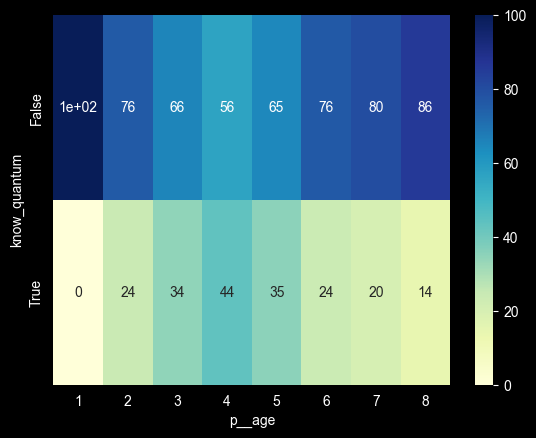

In [145]:
data_2023_df['know_quantum'] = data_2023_df['p__k02007'] > 2
#print(pd.crosstab(data_2023_df['p__k02007'], data_2023_df['p__age'], normalize='columns') * 100)
know_quantum_age = pd.crosstab(data_2023_df['know_quantum'], data_2023_df['p__age'], normalize='columns') * 100
sns.heatmap(know_quantum_age, annot=True, cmap='YlGnBu')
plt.show()

In [96]:
get_cramers_v('know_quantum', 'is_churned')

{'column': 'know_quantum',
 'p_value': np.float64(1.0672169536332693e-05),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.08982146395327936)}

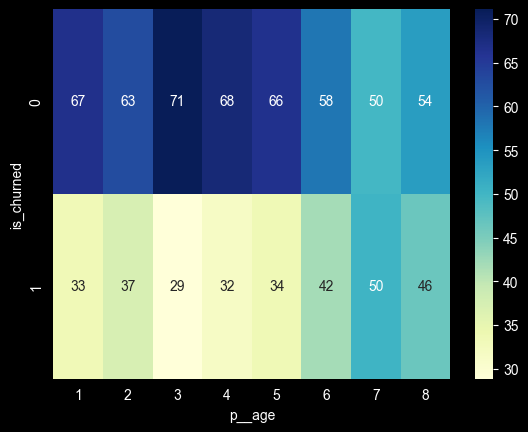

In [148]:
know_quantum_churn = pd.crosstab(data_2023_df['is_churned'],data_2023_df['p__age'], normalize='columns') * 100
sns.heatmap(know_quantum_churn, annot=True, cmap='YlGnBu')
plt.show()

In [149]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.9 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.5 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 3.3 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.4 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 3.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 3.6 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.5 MB 3.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 3.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 3.5 MB/s eta 0:00:01
   -----------------------

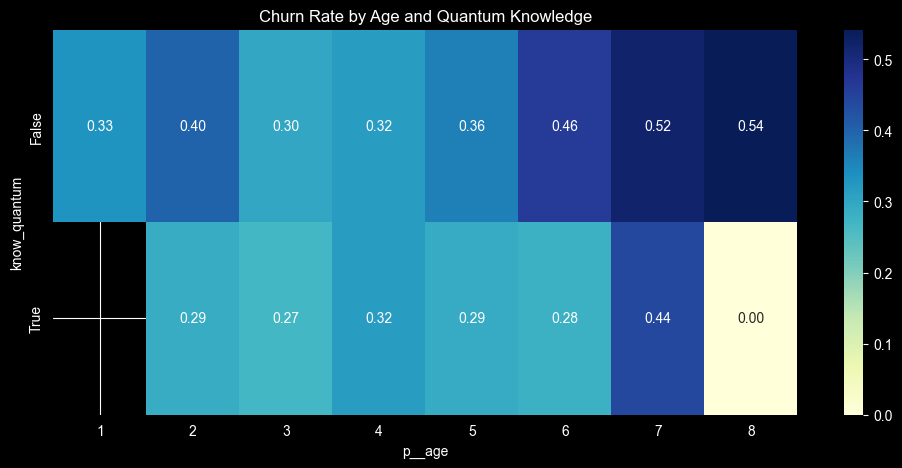

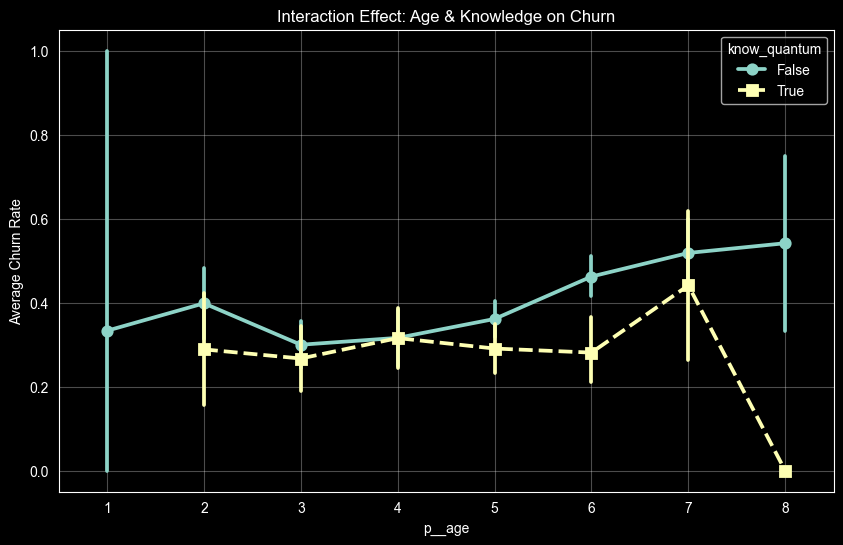

Optimization terminated successfully.
         Current function value: 0.646032
         Iterations 5

[로지스틱 회귀 분석 결과 요약]
                           Logit Regression Results                           
Dep. Variable:             is_churned   No. Observations:                 2280
Model:                          Logit   Df Residuals:                     2277
Method:                           MLE   Df Model:                            2
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                 0.01289
Time:                        16:13:39   Log-Likelihood:                -1473.0
converged:                       True   LL-Null:                       -1492.2
Covariance Type:            nonrobust   LLR p-value:                 4.404e-09
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.0580      0.156     -6.798      0.000      -1.363    

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\2821163622.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['know_quantum_int'] = df['know_quantum'].astype(int)


In [150]:
import statsmodels.api as sm

# 1. 시각화를 위한 피벗 테이블 생성 (나이 x 지식별 이탈률)
def plot_multivariate_heatmap(df):
    # 나이와 양자지식별 이탈률(is_churned의 평균) 계산
    pivot_df = df.pivot_table(index='know_quantum',
                             columns='p__age',
                             values='is_churned',
                             aggfunc='mean')

    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title('Churn Rate by Age and Quantum Knowledge')
    plt.show()

# 2. 상호작용 그래프 (Interaction Plot)
def plot_interaction(df):
    plt.figure(figsize=(10, 6))
    sns.pointplot(data=df, x='p__age', y='is_churned', hue='know_quantum', markers=["o", "s"], linestyles=["-", "--"])
    plt.title('Interaction Effect: Age & Knowledge on Churn')
    plt.ylabel('Average Churn Rate')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. 로지스틱 회귀 분석 (통계적 영향력 파악)
def perform_logistic_regression(df):
    # 범주형 변수 처리 (True/False -> 1/0)
    df['know_quantum_int'] = df['know_quantum'].astype(int)

    # 독립변수(X)와 종속변수(y) 설정
    X = df[['p__age', 'know_quantum_int']]
    X = sm.add_constant(X) # 상수항 추가
    y = df['is_churned']

    model = sm.Logit(y, X).fit()

    print("\n[로지스틱 회귀 분석 결과 요약]")
    print(model.summary())

    # Odds Ratio(오즈비) 계산: 각 변수가 1단위 증가할 때 이탈 확률이 몇 배 변하는지
    odds_ratios = np.exp(model.params)
    print("\n[Odds Ratios]")
    print(odds_ratios)

plot_multivariate_heatmap(data_2023_df)
plot_interaction(data_2023_df)
perform_logistic_regression(data_2023_df)

히트맵과 상호작용 그래프를 확인해 보면, 나이에 따라 이탈률이 증가하지만 신기술에 관심이 많으면 오히려 이탈률이 줄거나 완만하게 증가하는 현상이 나타남을 볼 수 있다.
그 이유는 마지막 로지스틱 회귀를 통해 확인할 수 있다. odds ratio를 보면, 나이에 비해 신기술에 대한 관심도가 훨씬 큰 영향을 줌을 알수있다.



## 챗봇에 대한 인식 정도

In [ ]:
data_2023_df['p__k06001'].value_counts().sort_index()

Spearman 점수 확인

In [133]:
get_spearman_score(data_2023_df, 'p__k06001')

🔍 [p__k06001] vs [is_churned] 분석 결과
  - Spearman's Rho: -0.0824
  - P-value: 8.1735e-05
  ✅ 결과: 통계적으로 유의미한 약함 음(-)의 상관관계 (수치가 커질수록 이탈률 감소)가 관찰됩니다.
----------------------------------------


## 인공지능 챗봇 이용 여부
443명만 이용해봄

In [85]:
data_2023_df['p__k06002'].value_counts().sort_index()

p__k06002
1.0     443
2.0    1837
Name: count, dtype: int64

Cramer's V 계산
유의 수준 기준(p < 0.05)에 맞지 않다

In [151]:
get_cramers_v(data_2023_df, 'p__k06002')

{'column': 'p__k06002',
 'p_value': np.float64(0.6433157347617481),
 'is_valid': np.False_,
 'cramers_v': np.float64(0.0)}

## 사용해본 사람들과 안써본 사람들의 이탈 여부 확인

In [86]:
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['p__k06002']))

p__k06002   1.0   2.0
is_churned           
0           278  1177
1           165   660


## 이용 목적

In [87]:
data_2023_df['p__k06003'].value_counts().sort_index() #일상 검색 가장많음, 그다음 업무, 그다음 공부

p__k06003
1.0    110
2.0     68
3.0    263
4.0      2
Name: count, dtype: int64

## 유료 서비스 사용 여부

In [88]:
data_2023_df['p__k06005'].value_counts().sort_index() #42명만씀

p__k06005
1.0     42
2.0    401
Name: count, dtype: int64

일단 챗봇 이용 목적 컬럼은 사용하기 어려워보인다.

In [91]:
data_2023_df['p__k06003'] = data_2023_df['p__k06003'].fillna(0) #일단 결측치 채워
get_cramers_v('p__k06003') #그래도 안될건 안돼.

{'column': 'p__k06003',
 'p_value': np.float64(0.06884327047798647),
 'is_valid': np.False_,
 'cramers_v': np.float64(0.04544003610694212)}

# [배경질문] 분석

In [97]:
csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', '../../00_data/01_interim/selected_data_2023.csv')
data_2023_df = pd.read_csv(csv_path)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\3516899775.py:2: DtypeWarning: Columns (0: p__d26019, 1: p__d26064, 2: p__d26068, 3: p__d27007, 4: p__d28003, 5: p__d22007, 6: p__d26062, 7: p__a03012, 8: p__l01012, 9: p__l01015, 10: p__l01028, 11: p__k06004, 12: p__relig3, 13: p__d26088) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2023_df = pd.read_csv(csv_path)


## 성별과 이탈

In [98]:
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['p__gender']))
# 남자 35.8%
# 여자 36.6% 유사하다

p__gender     1    2
is_churned          
0           700  755
1           390  435


## '현재' 배우자 있음/없음에 따라 비교

In [143]:
data_2023_df['cur_mar'] = (data_2023_df['p__mar'] == 2)
data_2023_df['cur_mar'].value_counts()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\1948228832.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_2023_df['cur_mar'] = (data_2023_df['p__mar'] == 2)


cur_mar
True     1383
False     897
Name: count, dtype: int64

In [144]:
get_cramers_v(data_2023_df, 'cur_mar')

{'column': 'cur_mar',
 'p_value': np.float64(0.012263558647776972),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.04809638105751673)}

## 나이에 대해 검정 수행

In [100]:
print(data_2023_df['p__age'].value_counts()) #40-49세 1위, 50-59세 2위, 20-29세 3위, 30-39세 4위, 10-19세 5위

p__age
5    624
6    539
3    381
4    348
2    188
7    169
8     28
1      3
Name: count, dtype: int64


In [153]:
data_2023_df = data_2023_df[data_2023_df['p__age']>1]
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['p__age'], normalize="columns") * 100) #연령대별 이탈률 차이가 크구나!!
get_spearman_score(data_2023_df, 'p__age')

p__age              2          3          4          5          6          7  \
is_churned                                                                     
0           62.765957  71.128609  68.390805  66.346154  58.070501  49.704142   
1           37.234043  28.871391  31.609195  33.653846  41.929499  50.295858   

p__age              8  
is_churned             
0           53.571429  
1           46.428571  
🔍 [p__age] vs [is_churned] 분석 결과
  - Spearman's Rho: 0.1030
  - P-value: 8.3691e-07
  ✅ 결과: 통계적으로 유의미한 약함 양(+)의 상관관계 (수치가 커질수록 이탈률 증가)가 관찰됩니다.
----------------------------------------


## 결혼 여부에 대해 검정 수행

In [102]:
get_cramers_v('cur_mar') #그다지 유의미하지 않다.

{'column': 'cur_mar',
 'p_value': np.float64(0.012338214333525329),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.0480789569724925)}

## 소득에 대해 검증 수행

In [103]:
data_2023_df['p__income'].value_counts()

p__income
1    642
5    602
6    493
7    182
4    157
8    129
3     36
2     36
Name: count, dtype: int64

In [104]:
data_2023_df['high_income'] = data_2023_df['p__income'] >5 #300 이상/이하
print(data_2023_df['high_income'].value_counts())
get_cramers_v('high_income')

high_income
False    1473
True      804
Name: count, dtype: int64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\3416005682.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_2023_df['high_income'] = data_2023_df['p__income'] >5 #300 이상/이하


{'column': 'high_income',
 'p_value': np.float64(0.005459601575814829),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.05433777519844026)}

## 직업에 대해 검증 수행

In [105]:
data_2023_df['p__job1'] = data_2023_df['p__job1'] == 1
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['p__job1']))
get_cramers_v('p__job1')

p__job1     False  True 
is_churned              
0             435   1018
1             277    547


{'column': 'p__job1',
 'p_value': np.float64(0.076322229200187),
 'is_valid': np.False_,
 'cramers_v': np.float64(0.03067124000438315)}

In [106]:
data_2023_df['p__job3'] = data_2023_df['p__job3'].fillna(0) #무직은 0으로
data_2023_df['p__job3'] = data_2023_df['p__job3']//10 #대분류로 묶자
print(data_2023_df['p__job3'].value_counts())
get_cramers_v('p__job3')

p__job3
0.0    712
3.0    531
2.0    294
5.0    222
4.0    169
8.0     98
7.0     94
1.0     71
9.0     67
6.0     19
Name: count, dtype: int64


{'column': 'p__job3',
 'p_value': np.float64(0.018370242673081672),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.06927549978206511)}

## 종교 분석

In [107]:
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['p__relig2']))

p__relig2   1.0  2.0  3.0  5.0  9.0
is_churned                         
0            86  217   87    1    0
1            62  109   47    2    4


In [108]:
data_2023_df['religion'] = data_2023_df['p__relig2'].fillna(0).astype(int)
data_2023_df['religion'] = data_2023_df['religion'].apply(lambda x: x if x in (0, 1, 2, 3) else 4)
print(pd.crosstab(data_2023_df['is_churned'], data_2023_df['religion']))

religion       0   1    2   3  4
is_churned                      
0           1062  86  217  87  1
1            600  62  109  47  6


C:\Users\Playdata\AppData\Local\Temp\ipykernel_5140\2093444691.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_2023_df['religion'] = data_2023_df['p__relig2'].fillna(0).astype(int)


In [109]:
get_cramers_v('religion')

{'column': 'religion',
 'p_value': np.float64(0.03056770772760936),
 'is_valid': np.True_,
 'cramers_v': np.float64(0.05411710938421272)}

### 중간 결론: Spearman 계수가 1을 넘는 나이를 제외하고는 이탈 여부와 `연관성 있는 컬럼이 없다

# 결론

두 파트를 분석한 결과 '신기술 관심도'(양자컴퓨팅) 와 '나이'(연령대로 구분) 컬럼이 어느 정도 연관성이 있는 것으로 나타남
두 컬럼 사이에도 연관성이 보이는 만큼, 어떻게 처리할지 추가 논의 필요